<a href="https://colab.research.google.com/github/ArthY07/Projet-Graphes-Et-Reseaux-L3/blob/main/Feschet_Arthur_Chayrigues_Noah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install osmnx
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import random
import time



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 7.4 MB/s eta 0:00:00


In [ ]:
# Projet Graphes et Réseaux
## Question 1
##On modèlise le problème à l'aide d'un graphe orienté valué G=(V,E) ou V est l'ensemble des adresses
##On considère aussi que E est l'ensemble des arêtes, ici des routes.
##On ajoute un arc de longueur d(i,j) de i vers j, s'il existe une route entre i et j. L'objectif est de trouver l'itinéraire le plus rapide entre
##le sommet de départ ((i) entrepôt) et une adresse (j) revient à trouver le plus court chemin entre i et j dans G.


In [ ]:
# Question 2
def find_min(N,pi):

  minimum= 999999999
  for x in N :
      if pi[x] < minimum:
          minimum=pi[x]
          resultat = x

  return resultat

def dijkstra_optimise(G, source, target):
    p = source
    parent = {}
    pi = {}
    noeuds_a_initialiser = list(G.nodes())
    i = 0
    while i < len(noeuds_a_initialiser):
        noeud_actuel = noeuds_a_initialiser[i]
        pi[noeud_actuel] = 9999999
        i += 1

    pi[source] = 0
    Q = [source]

    while Q:
        p = find_min(Q, pi)
        if p == target:
            break
        Q.remove(p)

        neighbors = [key for key in G[p]]
        for x in neighbors:
            # On adapte juste ces deux lignes aux données de la carte
            poids = G[p][x][0].get("travel_time", 1)

            if pi[x] > pi[p] + poids:
                pi[x] = pi[p] + poids
                parent[x] = p
                Q.append(x)

    chemin = [target]
    actuel = target
    while actuel != source:
        actuel = parent[actuel]
        chemin.append(actuel)

    chemin.reverse()
    return chemin, pi[target]

Lancement du benchmark...
Taille 100 terminée.
Taille 300 terminée.
Taille 500 terminée.
Taille 800 terminée.
Taille 1000 terminée.


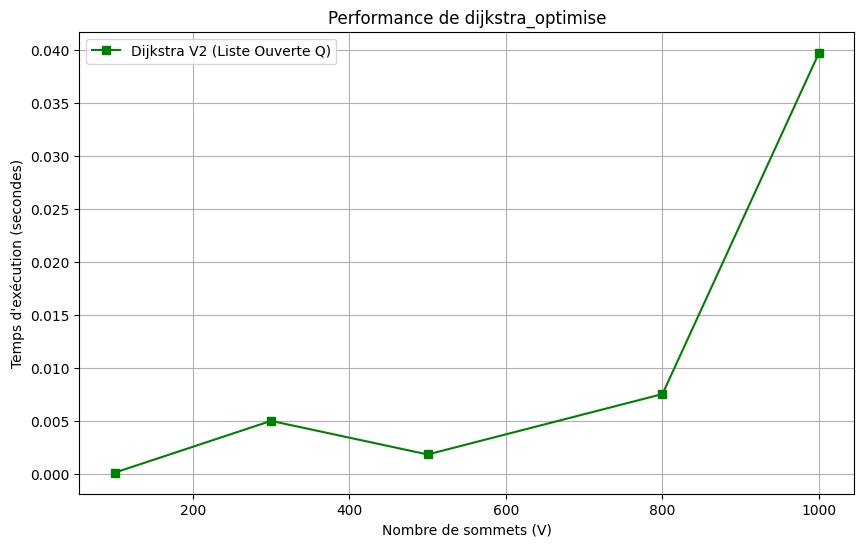

In [ ]:

# Question 3
sizes = [100, 300, 500, 800, 1000]
times_optimise = []

print("Lancement du benchmark...")

for n in sizes:
    G = nx.gnm_random_graph(n, n * 5, directed=False)
    G = nx.MultiGraph(G)

    for u, v, data in G.edges(data=True):
        data['travel_time'] = random.randint(1, 10)

    source = 0
    target = n - 1

    start = time.time()
    dijkstra_optimise(G, source, target)
    times_optimise.append(time.time() - start)

    print(f"Taille {n} terminée.")

plt.figure(figsize=(10, 6))
plt.plot(sizes, times_optimise, label='Dijkstra V2 (Liste Ouverte Q)', marker='s', color='green')
plt.title("Performance de dijkstra_optimise")
plt.xlabel("Nombre de sommets (V)")
plt.ylabel("Temps d'exécution (secondes)")
plt.legend()
plt.grid(True)
plt.show()


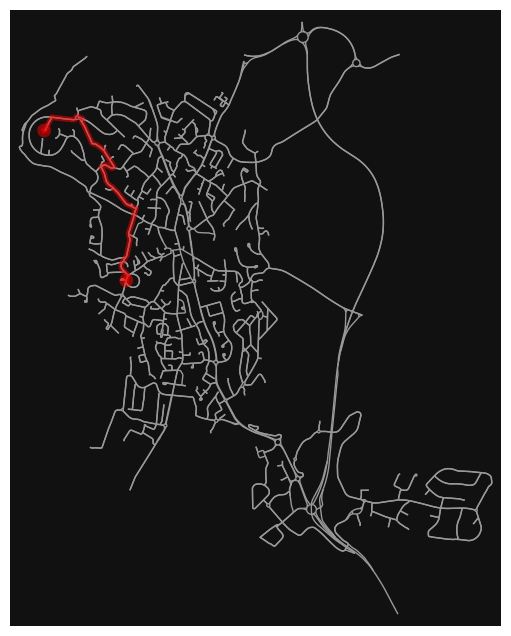

Temps de trajet estimé : 2.963606444275403 minutes
Temps de trajet estimé arrondi: 3.0 minutes


In [8]:
# Question 4
location = {
    "0": (3.801007, 43.690637),  # Entrepôt
    "1": (3.791705, 43.701633)   # Client
}

G = ox.graph_from_place("Saint-Gély-du-Fesc, France", network_type="drive")
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

for u, v, key, data in G.edges(keys=True, data=True):
    if 'travel_time' in data:
        data['weight'] = data['travel_time']

Entrepôt = ox.distance.nearest_nodes(G, location['0'][0], location['0'][1])
Client   = ox.distance.nearest_nodes(G, location['1'][0], location['1'][1])

chemin, duree = dijkstra_optimise(G, Entrepôt, Client)

fig, ax = ox.plot_graph_route(G, chemin, route_color='red', route_linewidth=4, node_size=0)
print(f"Temps de trajet estimé : {duree / 60} minutes")
print(f"Temps de trajet estimé arrondi: {round(duree / 60, 1)} minutes")

